In [133]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Read in Datasets

- For the St. Louis it says Billions in 2017 USD. This means that all the values are inflation-adjusted to 2017 Dollar Value. (Read GDP)

In [120]:
gdp = pd.read_csv('Datasets/GDP_St_Louis_Federal.csv')
gdp['GDPC1'] = gdp['GDPC1'] * 1_000_000_000
gdp

,observation_date,GDPC1
0,1947-01-01,2.182681e+12
1,1947-04-01,2.176892e+12
2,1947-07-01,2.172432e+12
3,1947-10-01,2.206452e+12
4,1948-01-01,2.239682e+12
...,...,...
310,2024-07-01,2.347857e+13
311,2024-10-01,2.358654e+13
312,2025-01-01,2.354821e+13
313,2025-04-01,2.377098e+13


In [122]:
gov_expend_invest = pd.read_csv('Datasets/Government_Consumption_Expenditures_and_Gross_Investment.csv')
gov_expend_invest['GCEC1'] = gov_expend_invest['GCEC1'] * 1_000_000_000

gov_expend_invest

,observation_date,GCEC1
0,1947-01-01,5.605150e+11
1,1947-04-01,5.600910e+11
2,1947-07-01,5.600340e+11
3,1947-10-01,5.555560e+11
4,1948-01-01,5.638950e+11
...,...,...
311,2024-10-01,4.003781e+12
312,2025-01-01,3.993923e+12
313,2025-04-01,3.992974e+12
314,2025-07-01,4.014983e+12


In [125]:
export_goods_services = pd.read_csv('Datasets/Net_Exports_of_Goods_and_Services.csv')
export_goods_services['NETEXC'] = export_goods_services['NETEXC'] * 1_000_000_000
export_goods_services

,observation_date,NETEXC
0,1970-01-01,-5.881100e+10
1,1970-04-01,-5.642600e+10
2,1970-07-01,-5.507400e+10
3,1970-10-01,-5.854600e+10
4,1971-01-01,-5.377100e+10
...,...,...
219,2024-10-01,-1.068994e+12
220,2025-01-01,-1.380718e+12
221,2025-04-01,-1.058037e+12
222,2025-07-01,-9.554920e+11


# Group Datasets from Quarterly to Yearly Totals

In [126]:
gdp['year'] = pd.to_datetime(gdp['observation_date']).dt.year
annual_gdp = gdp.groupby('year')['GDPC1'].sum().reset_index()
annual_gdp

,year,GDPC1
0,1947,8.738457e+12
1,1948,9.098506e+12
2,1949,9.047711e+12
3,1950,9.834127e+12
4,1951,1.062528e+13
...,...,...
74,2021,8.612963e+13
75,2022,8.830372e+13
76,2023,9.089488e+13
77,2024,9.343374e+13


In [123]:
gov_expend_invest['year'] = pd.to_datetime(gov_expend_invest['observation_date']).dt.year
annual_gov_expend_invest = gov_expend_invest.groupby('year')['GCEC1'].sum().reset_index()
annual_gov_expend_invest

,year,GCEC1
0,1947,2.236196e+12
1,1948,2.361928e+12
2,1949,2.616563e+12
3,1950,2.627850e+12
4,1951,3.593054e+12
...,...,...
74,2021,1.487456e+13
75,2022,1.469084e+13
76,2023,1.520275e+13
77,2024,1.578129e+13


In [127]:
export_goods_services['year'] = pd.to_datetime(export_goods_services['observation_date']).dt.year
annual_export_goods_services = export_goods_services.groupby('year')['NETEXC'].sum().reset_index()
annual_export_goods_services

,year,NETEXC
0,1970,-2.288570e+11
1,1971,-2.688610e+11
2,1972,-3.262460e+11
3,1973,-2.214990e+11
4,1974,-1.139220e+11
5,1975,1.232100e+10
6,1976,-1.489100e+11
7,1977,-2.610990e+11
8,1978,-2.619830e+11
9,1979,-1.614290e+11


# Combine Datasets

In [129]:
overview = pd.merge(annual_gdp, annual_gov_expend_invest, on='year', how='left')
overview = pd.merge(overview, annual_export_goods_services, on='year', how='left')
overview

,year,GDPC1,GCEC1,NETEXC
0,1947,8.738457e+12,2.236196e+12,NaN
1,1948,9.098506e+12,2.361928e+12,NaN
2,1949,9.047711e+12,2.616563e+12,NaN
3,1950,9.834127e+12,2.627850e+12,NaN
4,1951,1.062528e+13,3.593054e+12,NaN
...,...,...,...,...
74,2021,8.612963e+13,1.487456e+13,-3.705485e+12
75,2022,8.830372e+13,1.469084e+13,-4.097492e+12
76,2023,9.089488e+13,1.520275e+13,-3.700621e+12
77,2024,9.343374e+13,1.578129e+13,-4.130275e+12


# Analytics

## Correlation

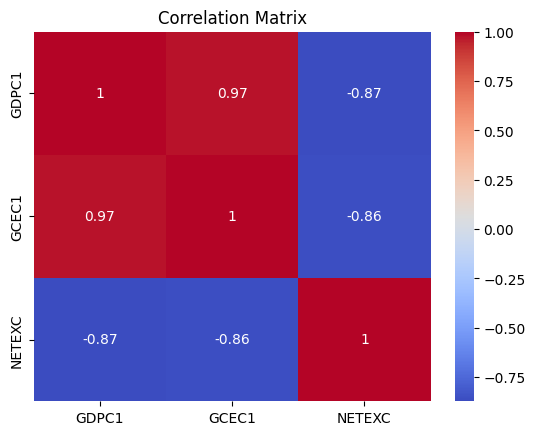

In [134]:
corr_df = overview[overview['NETEXC'].notna()]
sns.heatmap(corr_df[['GDPC1', 'GCEC1', 'NETEXC']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()